In [1]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class MVTecLOCODataset(Dataset):
    def __init__(self, root_dir, split='train', anomaly_type='logical_anomalies', transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []  # 0 for normal, 1 for anomaly

        if split == 'train':
            # Load 'good' images for training
            good_dir = os.path.join(root_dir, 'train', 'good')
            self._load_images_from_folder(good_dir, label=0)
        elif split == 'test':
            # Load 'good' and specified anomalies for testing
            good_dir = os.path.join(root_dir, 'test', 'good')
            anomaly_dir = os.path.join(root_dir, 'test', anomaly_type)
            self._load_images_from_folder(good_dir, label=0)
            self._load_images_from_folder(anomaly_dir, label=1)
        else:
            raise ValueError(f"Invalid split: {split}")

    def _load_images_from_folder(self, folder, label):
        if not os.path.isdir(folder):
            print(f"Folder {folder} is missing!")
            return
        for root, _, files in os.walk(folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, file)
                    self.image_paths.append(img_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label, img_path


In [2]:
import torch
import torch.nn as nn

class Patches(nn.Module):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def forward(self, images):
        # images: (batch_size, channels, height, width)
        unfold = nn.Unfold(kernel_size=self.patch_size, stride=self.patch_size)
        patches = unfold(images)  # (batch_size, patch_dim, num_patches)
        patches = patches.transpose(1, 2)  # (batch_size, num_patches, patch_dim)
        return patches


In [3]:
class PatchEncoder(nn.Module):
    def __init__(self, embed_shape, patch_dim):
        super(PatchEncoder, self).__init__()
        self.position_embedding = nn.Embedding(embed_shape[0], embed_shape[1])
        self.projection = nn.Linear(patch_dim, embed_shape[1])  # Corrected input dimension

    def forward(self, patches):
        batch_size, num_patches, patch_dim = patches.size()
        positions = torch.arange(num_patches, device=patches.device).unsqueeze(0).expand(batch_size, num_patches)
        # Correctly project from patch_dim to embed_shape[1]
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded


In [4]:
class PatchExpanding(nn.Module):
    def __init__(self, image_size, patch_size, num_channels):
        super(PatchExpanding, self).__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_channels = num_channels

    def forward(self, patches):
        """
        Reconstruct the image from patches.
        patches: Tensor of shape (batch_size, num_patches, embed_dim)
        """
        batch_size, num_patches, embed_dim = patches.size()
        num_patches_per_dim = int(self.image_size / self.patch_size)

        # Project back to patch dimensions if needed
        patch_dim = self.patch_size * self.patch_size * self.num_channels
        patches = patches.view(batch_size, num_patches, patch_dim)

        # Reshape to (batch_size, num_channels, image_height, image_width)
        patches = patches.transpose(1, 2)  # (batch_size, patch_dim, num_patches)
        fold = nn.Fold(output_size=(self.image_size, self.image_size),
                       kernel_size=self.patch_size, stride=self.patch_size)
        images = fold(patches)  # (batch_size, num_channels, image_size, image_size)
        return images


In [5]:
class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, drop=0.):
        super(Mlp, self).__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.drop = nn.Dropout(drop)
        self.fc2 = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super(TransformerBlock, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.mlp = Mlp(embed_dim, hidden_features=4 * embed_dim, drop=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: (sequence_length, batch_size, embed_dim)
        attn_output, _ = self.attn(x, x, x)
        x = x + attn_output  # Residual connection
        x = self.norm1(x)
        mlp_output = self.mlp(x.transpose(0, 1))  # Transpose for MLP
        x = x + mlp_output.transpose(0, 1)  # Residual connection
        x = self.norm2(x)
        return x


In [7]:
# class DCAE(nn.Module):
#     def __init__(self, num_channels=3):
#         super(DCAE, self).__init__()
#         # Encoder
#         self.encoder_conv1 = nn.Conv2d(num_channels, 32, 3, stride=2, padding=1)   # Output: (batch_size, 32, 512, 512)
#         self.encoder_conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)             # Output: (batch_size, 64, 256, 256)
#         self.encoder_conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)            # Output: (batch_size, 128, 128, 128)
#         self.encoder_conv4 = nn.Conv2d(128, 128, 3, stride=2, padding=1)           # Output: (batch_size, 128, 64, 64)
#         self.encoder_conv5 = nn.Conv2d(128, 16, 1)                                 # Output: (batch_size, 16, 64, 64)

#         self.leaky_relu = nn.LeakyReLU(inplace=True)

#         # Fully connected layers
#         self.fc1 = nn.Linear(16 * 64 * 64, 512)
#         self.fc2 = nn.Linear(512, 16 * 64 * 64)

#         # Decoder without skip connections
#         self.decoder_deconv1 = nn.ConvTranspose2d(16, 128, 3, stride=2, padding=1, output_padding=1)   # Output: (batch_size, 128, 128, 128)
#         self.decoder_deconv2 = nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1)  # Output: (batch_size, 128, 256, 256)
#         self.decoder_deconv3 = nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1)   # Output: (batch_size, 64, 512, 512)
#         self.decoder_deconv4 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)    # Output: (batch_size, 32, 1024, 1024)
#         self.decoder_conv_final = nn.Conv2d(32, num_channels, 1)                                       # Output: (batch_size, num_channels, 1024, 1024)

#     def forward(self, x):
#         # Encoder
#         x = self.leaky_relu(self.encoder_conv1(x))  # (batch_size, 32, 512, 512)
#         x = self.leaky_relu(self.encoder_conv2(x))  # (batch_size, 64, 256, 256)
#         x = self.leaky_relu(self.encoder_conv3(x))  # (batch_size, 128, 128, 128)
#         x = self.leaky_relu(self.encoder_conv4(x))  # (batch_size, 128, 64, 64)
#         x = self.leaky_relu(self.encoder_conv5(x))  # (batch_size, 16, 64, 64)

#         # Flatten and bottleneck
#         x_flat = x.view(x.size(0), -1)
#         x_flat = self.leaky_relu(self.fc1(x_flat))    # (batch_size, 512)
#         x_flat = self.leaky_relu(self.fc2(x_flat))    # (batch_size, 16 * 64 * 64)

#         # Reshape to image dimensions
#         x_unflat = x_flat.view(x.size(0), 16, 64, 64)

#         # Decoder without skip connections
#         x_unflat = self.leaky_relu(self.decoder_deconv1(x_unflat))  # (batch_size, 128, 128, 128)
#         x_unflat = self.leaky_relu(self.decoder_deconv2(x_unflat))  # (batch_size, 128, 256, 256)
#         x_unflat = self.leaky_relu(self.decoder_deconv3(x_unflat))  # (batch_size, 64, 512, 512)
#         x_unflat = self.leaky_relu(self.decoder_deconv4(x_unflat))  # (batch_size, 32, 1024, 1024)
#         x_unflat = self.decoder_conv_final(x_unflat)                # (batch_size, num_channels, 1024, 1024)

#         return x_unflat


In [8]:
class DCAE(nn.Module):
    def __init__(self, num_channels=3):
        super(DCAE, self).__init__()
        # Encoder
        self.encoder_conv1 = nn.Conv2d(num_channels, 32, 3, stride=2, padding=1)
        self.encoder_conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.encoder_conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.encoder_conv4 = nn.Conv2d(128, 128, 3, stride=2, padding=1)
        self.encoder_conv5 = nn.Conv2d(128, 16, 1)

        self.leaky_relu = nn.LeakyReLU(inplace=True)

        # Fully connected layers
        self.fc1 = nn.Linear(16 * 64 * 64, 512)
        self.fc2 = nn.Linear(512, 16 * 64 * 64)

        # Decoder
        self.decoder_deconv1 = nn.ConvTranspose2d(16, 128, 3, stride=2, padding=1, output_padding=1)
        self.decoder_deconv2 = nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1)
        self.decoder_deconv3 = nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1)
        self.decoder_deconv4 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.decoder_deconv5 = nn.Conv2d(32, num_channels, 1)

    def forward(self, x):
        # Encoder
        x1 = self.leaky_relu(self.encoder_conv1(x))   # (batch_size, 32, 512, 512)
        x2 = self.leaky_relu(self.encoder_conv2(x1))  # (batch_size, 64, 256, 256)
        x3 = self.leaky_relu(self.encoder_conv3(x2))  # (batch_size, 128, 128, 128)
        x4 = self.leaky_relu(self.encoder_conv4(x3))  # (batch_size, 128, 64, 64)
        x5 = self.leaky_relu(self.encoder_conv5(x4))  # (batch_size, 16, 64, 64)

        # Flatten and bottleneck
        x_flat = x5.view(x.size(0), -1)
        x_flat = self.leaky_relu(self.fc1(x_flat))    # (batch_size, 512)
        x_flat = self.leaky_relu(self.fc2(x_flat))    # (batch_size, 16 * 64 * 64)

        # Reshape to image dimensions
        x_unflat = x_flat.view(x.size(0), 16, 64, 64)

        # Decoder with skip connections
        x_unflat = self.leaky_relu(self.decoder_deconv1(x_unflat))  # (batch_size, 128, 128, 128)

        # Upsample x4
        x4_upsampled = nn.functional.interpolate(x4, size=(128, 128), mode='nearest')

        # Add skip connection and pass through next deconvolution
        x_unflat = self.leaky_relu(self.decoder_deconv2(x_unflat + x4_upsampled))  # (batch_size, 128, 256, 256)

        # Upsample x3
        x3_upsampled = nn.functional.interpolate(x3, size=(256, 256), mode='nearest')

        # Add skip connection
        x_unflat = self.leaky_relu(self.decoder_deconv3(x_unflat + x3_upsampled))  # (batch_size, 64, 512, 512)

        # Upsample x2
        x2_upsampled = nn.functional.interpolate(x2, size=(512, 512), mode='nearest')

        # Add skip connection
        x_unflat = self.leaky_relu(self.decoder_deconv4(x_unflat + x2_upsampled))  # (batch_size, 32, 1024, 1024)

        # Upsample x1
        x1_upsampled = nn.functional.interpolate(x1, size=(1024, 1024), mode='nearest')

        # Add skip connection and output layer
        x_unflat = self.decoder_deconv5(x_unflat + x1_upsampled)  # (batch_size, num_channels, 1024, 1024)

        return x_unflat


In [10]:
class TransformerAutoencoder(nn.Module):
    def __init__(self, image_size, patch_size, num_channels, embed_shape, num_heads, transformer_layers, dropout=0.1):
        super(TransformerAutoencoder, self).__init__()

        # Patch extraction
        self.patches = Patches(patch_size)

        # Calculate patch dimension
        self.patch_dim = patch_size * patch_size * num_channels

        # Patch embedding
        self.patch_encoder = PatchEncoder(embed_shape, patch_dim=self.patch_dim)

        # Transformer encoder layers
        self.transformer_layers = nn.ModuleList([
            TransformerBlock(embed_shape[1], num_heads, dropout) for _ in range(transformer_layers)
        ])

        # Patch expanding layer
        self.patch_expanding = PatchExpanding(image_size, patch_size, num_channels)

        # Convolutional Autoencoder
        self.conv_autoencoder = DCAE(num_channels=num_channels)

        # Positional Embeddings for decoder
        self.pos_embedding = nn.Embedding(embed_shape[0], embed_shape[1])

        # Transformer decoder layers
        self.decoder_attn1 = nn.MultiheadAttention(embed_dim=embed_shape[1], num_heads=num_heads, dropout=dropout)
        self.decoder_norm1 = nn.LayerNorm(embed_shape[1])

        self.decoder_attn2 = nn.MultiheadAttention(embed_dim=embed_shape[1], num_heads=num_heads, dropout=dropout)
        self.decoder_norm2 = nn.LayerNorm(embed_shape[1])

        self.decoder_mlp = Mlp(embed_shape[1], hidden_features=4 * embed_shape[1], drop=dropout)
        self.decoder_norm3 = nn.LayerNorm(embed_shape[1])

    def forward(self, x):
        # Extract patches
        patches = self.patches(x)  # (batch_size, num_patches, patch_dim)

        # Encode patches
        encoded_patches = self.patch_encoder(patches)  # (batch_size, num_patches, embed_dim)

        # Prepare for MultiheadAttention (sequence_length, batch_size, embed_dim)
        encoded_patches = encoded_patches.permute(1, 0, 2)

        # Transformer encoder
        for transformer in self.transformer_layers:
            encoded_patches = transformer(encoded_patches)

        # Revert dimensions back to (batch_size, num_patches, embed_dim)
        encoded_patches = encoded_patches.permute(1, 0, 2)

        # Expand patches back to image
        expanded_image = self.patch_expanding(encoded_patches)

        # Pass through convolutional autoencoder
        decoded_img = self.conv_autoencoder(expanded_image)

        # Re-extract patches from decoded image
        decoded_patches = self.patches(decoded_img)

        # Encode decoded patches
        decoded_patches_encoded = self.patch_encoder(decoded_patches)

        # Add positional embeddings
        batch_size, num_patches, _ = decoded_patches_encoded.size()
        positions = torch.arange(num_patches, device=decoded_patches_encoded.device).unsqueeze(0).expand(batch_size, num_patches)
        pos_embed = self.pos_embedding(positions)
        target = decoded_patches_encoded + pos_embed

        # Prepare for MultiheadAttention
        target = target.permute(1, 0, 2)  # (sequence_length, batch_size, embed_dim)
        encoded_patches = encoded_patches.permute(1, 0, 2)

        # Decoder Transformer layers

        # Self-attention layer
        attn_output1, _ = self.decoder_attn1(target, target, target)
        target = target + attn_output1
        target = self.decoder_norm1(target)

        # Cross-attention layer
        attn_output2, _ = self.decoder_attn2(target, encoded_patches, encoded_patches)
        target = target + attn_output2
        target = self.decoder_norm2(target)

        # MLP layer
        mlp_output = self.decoder_mlp(target.permute(1, 0, 2))  # Transpose for MLP
        target = target + mlp_output.permute(1, 0, 2)
        target = self.decoder_norm3(target)

        # Revert dimensions back to (batch_size, num_patches, embed_dim)
        target = target.permute(1, 0, 2)

        # Expand patches back to image
        reconstructed_image = self.patch_expanding(target)

        return reconstructed_image, expanded_image, decoded_img


In [11]:
def visualize_transformer_output(model, dataloader, device):
    import numpy as np
    import matplotlib.pyplot as plt

    model.eval()
    images, labels, paths = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        reconstructed_image, expanded_image, decoded_img = model(images)  # Get the expanded image after transformer encoder

    # Convert to NumPy and transpose dimensions for visualization (batch, height, width, channels)
    images = images.cpu().numpy().transpose(0, 2, 3, 1)
    expanded_image = expanded_image.cpu().numpy().transpose(0, 2, 3, 1)
    decoded_img = decoded_img.cpu().numpy().transpose(0, 2, 3, 1)
    reconstructed_image = reconstructed_image.cpu().numpy().transpose(0, 2, 3, 1)

    # Rescale images from [-1, 1] to [0, 1]
    images = (images * 0.5) + 0.5
    expanded_image = (expanded_image * 0.5) + 0.5
    decoded_img = (decoded_img * 0.5) + 0.5
    reconstructed_image = (reconstructed_image * 0.5) + 0.5

    # Clip values to ensure valid image range
    images = np.clip(images, 0, 1)
    expanded_image = np.clip(expanded_image, 0, 1)
    decoded_img = np.clip(decoded_img, 0, 1)
    reconstructed_image = np.clip(reconstructed_image, 0, 1)

    n = min(len(images), 4)  # Limit to 4 images for visualization
    plt.figure(figsize=(18, 8))
    for i in range(n):
        # Original Image
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(images[i])
        ax.axis('off')
        ax.set_title("Original")

        # Expanded Image (After Transformer Encoder)
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(expanded_image[i])
        ax.axis('off')
        ax.set_title("After Transformer Encoder")

        # Decoded Image (After Conv. Autoencoder)
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(decoded_img[i])
        ax.axis('off')
        ax.set_title("Decoded Image (Conv AE)")

    plt.show()



In [12]:
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
import tqdm

def evaluate(model, dataloader, device):
    model.eval()
    all_labels = []
    all_scores = []

    with torch.no_grad():
        for images, labels, _ in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            reconstructed, expanded_image, decoded_img = model(images)
            # Compute per-sample reconstruction error
            reconstruction_error = F.mse_loss(reconstructed, images, reduction='none')
            reconstruction_error = reconstruction_error.view(reconstruction_error.size(0), -1)
            reconstruction_error = reconstruction_error.mean(dim=1)

            # Collect labels and scores
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(reconstruction_error.cpu().numpy())

    # Compute AUROC
    auroc = roc_auc_score(all_labels, all_scores)
    return auroc

def visualize_reconstruction(model, dataloader, device):
    import numpy as np
    import matplotlib.pyplot as plt

    model.eval()
    images, labels, paths = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        reconstructed, expanded_image, decoded_img = model(images)

    images = images.cpu().numpy().transpose(0, 2, 3, 1)
    reconstructed = reconstructed.cpu().numpy().transpose(0, 2, 3, 1)

    # Rescale images from [-1, 1] to [0, 1]
    images = (images * 0.5) + 0.5
    reconstructed = (reconstructed * 0.5) + 0.5

    images = np.clip(images, 0, 1)
    reconstructed = np.clip(reconstructed, 0, 1)

    n = min(len(images), 4)
    plt.figure(figsize=(12, 6))
    for i in range(n):
        # Original Image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i])
        ax.axis('off')
        ax.set_title("Original")

        # Reconstructed Image
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i])
        ax.axis('off')
        ax.set_title("Reconstructed")

    plt.show()

def train(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    progress_bar = tqdm.tqdm(train_loader, desc="Training", unit="batch")

    for images, labels, _ in progress_bar:
        images = images.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        reconstructed, expanded_image, decoded_img = model(images)
        loss = criterion(reconstructed, images)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Accumulate the loss
        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return total_loss / len(train_loader)


Training: 100%|██████████| 360/360 [02:24<00:00,  2.48batch/s, loss=1.25]


Epoch 1/50, Train Loss: 1.315494, Test AUROC: 0.5573


Training: 100%|██████████| 360/360 [02:33<00:00,  2.34batch/s, loss=1.09]


Epoch 2/50, Train Loss: 1.149110, Test AUROC: 0.5597


Training: 100%|██████████| 360/360 [02:28<00:00,  2.42batch/s, loss=0.978]


Epoch 3/50, Train Loss: 1.037063, Test AUROC: 0.5590


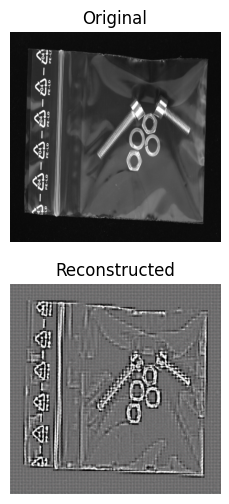

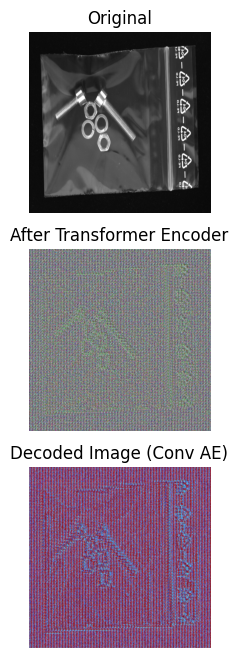

Training:  84%|████████▍ | 304/360 [02:05<00:23,  2.43batch/s, loss=0.895]


KeyboardInterrupt: 

In [18]:
import torchvision.transforms as transforms
from PIL import Image

class GrayscaleTo3Channels(object):
    def __call__(self, img):
        # Convert the image to grayscale (single channel)
        img = transforms.functional.rgb_to_grayscale(img, num_output_channels=1)
        # Convert the image to a tensor
        img = transforms.functional.to_tensor(img)  # Now it's a single-channel tensor
        # Repeat the single channel across R, G, B channels
        img = img.repeat(3, 1, 1)  # Repeat across the channel dimension (3 channels)
        # Convert the tensor back to a PIL image
        img = transforms.functional.to_pil_image(img)
        return img

# Updated Transform Pipeline Example:
transform = transforms.Compose([
    transforms.Resize((1024, 1024)),  # Resize the image
    GrayscaleTo3Channels(),           # Convert it to a 3-channel grayscale-like image
    transforms.ToTensor(),            # Convert to tensor for further operations
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),  # Normalize as if it were an RGB image
])

def main():
    # Hyperparameters
    num_epochs = 50
    learning_rate = 1e-4
    
    img_size = 1024
    num_channels = 3
    batch_size = 1
    
    patch_size = 16
    transformer_layers = 2
    num_heads = 16
    
    ROOT_DIR = "/home/hafiz/my_thesis/seg_recons/dataset/screw_bag"  # Update this path
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

    # Data Transformations
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        GrayscaleTo3Channels(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])

    # Datasets and Data Loaders
    train_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='train', transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    test_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='test', transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Initialize Model
    num_patches = (img_size // patch_size) ** 2
    embed_dim = patch_size * patch_size * num_channels
    embed_shape = (num_patches, embed_dim)

    model = TransformerAutoencoder(
        image_size=img_size,
        patch_size=patch_size,
        num_channels=num_channels,
        embed_shape=embed_shape,
        num_heads=num_heads,
        transformer_layers=transformer_layers,
        dropout=0.1
    ).to(device)

    # Optimizer and Loss Function
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # Training Loop
    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, optimizer, criterion, device)
        auroc = evaluate(model, test_loader, device)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Test AUROC: {auroc:.4f}")

        # Visualize reconstructed images every 5 epochs
        if (epoch + 1) % 3 == 0:
            visualize_reconstruction(model, test_loader, device)
            visualize_transformer_output(model, test_loader, device)

        # Save model checkpoint every 25 epochs
        if (epoch + 1) % 25 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, f'checkpoint_epoch_{epoch+1}.pth')

    # Save the final model and optimizer states
    torch.save(model.state_dict(), 'model_final.pth')
    torch.save(optimizer.state_dict(), 'optimizer_final.pth')

if __name__ == "__main__":
    main()
